# Caso — Evolución temática del corpus 23F

## Planteamiento

El corpus del 23F cubre un arco temporal completo del episodio histórico, desde los
meses previos al golpe hasta los recursos posteriores a la sentencia. La columna
`fase` del dataset master ordena los 167 documentos en seis fases consecutivas:
**pre-golpe, noche del golpe, días inmediatos, instrucción, juicio oral,
post-sentencia**.

Una crisis política compleja como el 23F no se cuenta igual mientras está pasando
que cuando ya ha pasado: el lenguaje operativo de los partes telegráficos (órdenes,
movimientos de tropas) no es el lenguaje analítico de los días siguientes (Rey,
Constitución, transición), ni el lenguaje procesal del juicio (fiscal, defensa,
sentencia). La hipótesis del caso es que esa diferencia no es solo cualitativa: es
**cuantificable y detectable** mediante topic modeling aplicado por fases.

### Objeto de interés

> **Demostrar cuantitativamente cómo cambia el foco temático del corpus a medida
> que avanza el proceso del 23F, identificar el momento exacto en que se produce
> el "pivote" discursivo, y caracterizar qué temas son tempranos, cuáles tardíos
> y cuáles atraviesan todo el proceso.**

### Pregunta de investigación

¿En qué fase del proceso cambia la conversación del corpus, y de qué a qué cambia?

### Hipótesis

1. Las fases tempranas (pre-golpe, noche, días inmediatos) están dominadas por
   temas operativos: comunicaciones militares, partes de situación, mando y control.
2. Las fases intermedias (instrucción) introducen un giro hacia temas
   procesales: declaraciones, autos, calificaciones jurídicas.
3. Las fases finales (juicio oral, post-sentencia) consolidan el discurso
   procesal y reincorporan el análisis político.
4. Existirá un **"momento pivote"** — una fase en la que la composición
   temática cambia más bruscamente respecto a la anterior. Identificarlo señala
   cuándo el episodio dejó de ser una crisis operativa y pasó a ser un
   proceso institucional.

### Entidad propia respecto a otros casos del proyecto

A diferencia de un caso de clasificación supervisada, aquí no se predice una
etiqueta. A diferencia de un topic modeling estático (que solo describe los
temas), aquí se analiza la **dinámica temporal** del corpus: cómo cambia el peso
de cada tema fase a fase, qué temas son tempranos o tardíos, y dónde está el
punto de inflexión narrativo. El resultado es una caracterización cuantitativa de
la **evolución del discurso histórico**, no de su composición instantánea.

### Aplicación práctica

El método es generalizable: dado cualquier corpus histórico documentado por
fases procesales o cronológicas, identifica automáticamente cuándo cambia el
foco discursivo. Útil para análisis de crisis políticas, conflictos
prolongados o procesos institucionales largos.


In [1]:
# === Setup ===
import os, re, json, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import jensenshannon

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
print("Setup OK")


Setup OK


## 1. Carga del dataset

Usamos `dataset_23f_master.csv`, que incluye la columna `fase` con las seis
fases del proceso 23F.


In [ ]:
df = pd.read_csv("dataset_23f_master.csv")
df["texto_completo"] = df["texto_completo"].fillna("")
df = df[df["texto_completo"].str.strip() != ""].reset_index(drop=True)
print(f"Documentos: {len(df)}")
print()
print("Distribución por fase:")
print(df["fase"].value_counts().sort_index())


Usando: dataset_23f_master.csv


Documentos: 167

Distribución por fase:
fase
1_pre_golpe          10
2_noche_golpe        22
3_dias_inmediatos    17
4_instruccion        48
5_juicio_oral        63
6_post_sentencia      7
Name: count, dtype: int64


## 2. EDA específico — el corpus visto por fases

Antes del modelado, miramos cuántos documentos tenemos por fase y la longitud
media de cada fase. Esto es importante porque:

- Una fase con muy pocos documentos puede dar topic modeling inestable.
- Las fases con documentos muy largos (la noche del golpe, por las
  transcripciones) pueden dominar visualmente si no normalizamos.


In [3]:
df["n_palabras"] = df["texto_completo"].str.split().str.len()
fases_orden = ["1_pre_golpe","2_noche_golpe","3_dias_inmediatos",
               "4_instruccion","5_juicio_oral","6_post_sentencia"]
df["fase"] = pd.Categorical(df["fase"], categories=fases_orden, ordered=True)

resumen = df.groupby("fase").agg(
    n_docs=("texto_completo","count"),
    palabras_totales=("n_palabras","sum"),
    palabras_media=("n_palabras","mean"),
    palabras_mediana=("n_palabras","median"),
).round(0).astype(int)
print("Resumen por fase:")
print(resumen)


Resumen por fase:
                   n_docs  palabras_totales  palabras_media  palabras_mediana
fase                                                                         
1_pre_golpe            10             18188            1819               428
2_noche_golpe          22            149264            6785              1162
3_dias_inmediatos      17             15392             905               207
4_instruccion          48             64625            1346               259
5_juicio_oral          63             91953            1460              1475
6_post_sentencia        7              7177            1025               554


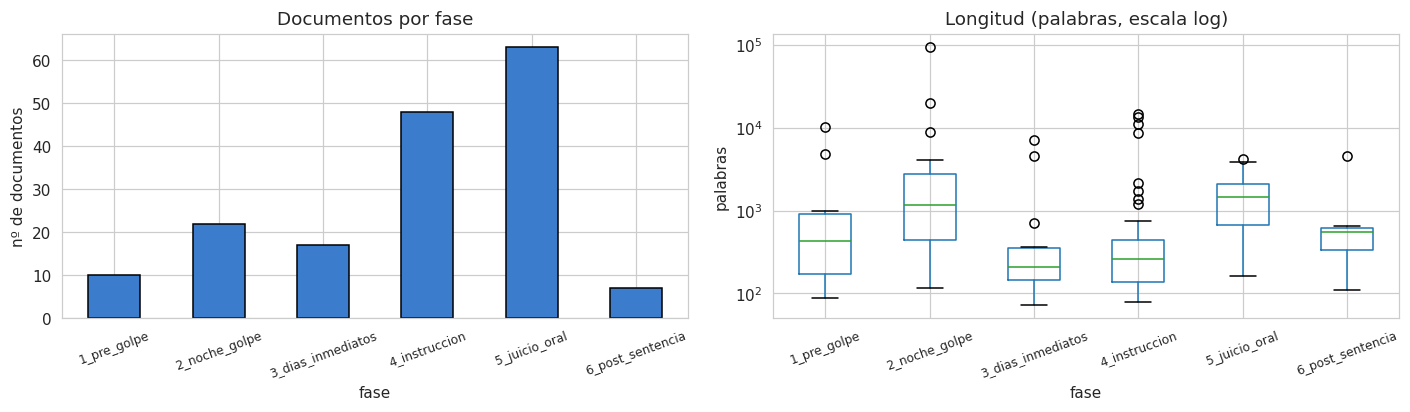

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df["fase"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="#3B7CCC", edgecolor="black"
)
axes[0].set_title("Documentos por fase")
axes[0].set_ylabel("nº de documentos")
axes[0].tick_params(axis="x", rotation=20, labelsize=8)

df.boxplot(column="n_palabras", by="fase", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Longitud (palabras, escala log)")
axes[1].set_ylabel("palabras")
axes[1].tick_params(axis="x", rotation=20, labelsize=8)
plt.suptitle("")
plt.tight_layout(); plt.show()


## 3. Preprocesado y vectorización TF-IDF

Limpieza ligera + stopwords del español + stopwords de dominio (palabras
ubicuas en el corpus que no diferencian temas, como nombres de meses o
"documento"). Vectorizamos con TF-IDF de unigramas y bigramas.


In [5]:
SW_BASE = set('''
a al algo algún alguna alguno algunas algunos ante antes así aún aunque
bajo bastante bien cada casi como con contra cual cuales cualquier cualquiera
cualquieras cuando cuanto cuantos cuál cuáles cuándo cuánto cuántos cómo
de del desde donde dos durante donde durante e el ella ellas ellos en entre
era eran eras eres es esa esas ese eso esos esta estas este esto estos
está están estaba estaban estamos estar estaría estaríamos esté estén
estuve estuvo etc. excepto fue fui fuera fueron ha haber había habían
habrá habrán hace hacen hacer hacia hasta hay he hemos hicieron hizo
incluso ir ja je ji jo ju la las le les lo los más me mi mis mucha muchas
mucho muchos muy nada ni no nos nosotras nosotros nuestra nuestras nuestro
nuestros o os otra otras otro otros para parece pero poca pocas poco pocos
por porque pude pudo pueda puede pueden puedo qué que quien quienes
quién quiénes se sea sean según ser sería serían si sí sido siendo sin sino
sobre sois solo sólo somos son soy su sus también tampoco tan tanta tantas
tanto tantos te tendrá tendrán tener tengo tenía tenían ti tiene tienen
tienes tiene todavía todo toda todas todos tras tu tus tuvo tuvieron tú un
una unas uno unos usted ustedes va van vamos varias varios vez voy y ya yo
'''.split())

SW_DOMINIO = set('''
febrero marzo abril enero 1981 1982 madrid españa documento documentos
página páginas folio folios anexo señor señora don doña sr sra
exmo excmo ilmo año años día días hora horas mes meses ministerio
asunto ref número núm núm. nº n° cm
'''.split())

STOPWORDS_ES = SW_BASE | SW_DOMINIO


def limpia(text: str) -> str:
    t = text.lower()
    t = re.sub(r"[^a-záéíóúüñ\s]", " ", t)
    t = re.sub(r"\b\w{1,2}\b", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t


df["texto_limpio"] = df["texto_completo"].apply(limpia)

vectorizer = TfidfVectorizer(
    stop_words=list(STOPWORDS_ES),
    ngram_range=(1, 2),
    min_df=2, max_df=0.85,
    sublinear_tf=True, norm="l2",
)
X = vectorizer.fit_transform(df["texto_limpio"])
vocab = np.array(vectorizer.get_feature_names_out())
print(f"Matriz TF-IDF: {X.shape[0]} docs × {X.shape[1]} términos")


Matriz TF-IDF: 167 docs × 15391 términos


## 4. Topic modeling con NMF

Aplicamos NMF con k=10 temas sobre el corpus completo. El NMF descompone la
matriz documento×término en dos matrices no negativas: documento×tema (W) y
tema×término (H). Cada documento queda representado como una mezcla de los
10 temas.


In [6]:
K = 10
nmf = NMF(n_components=K, init="nndsvda", random_state=RANDOM_STATE,
          max_iter=600, tol=1e-5)
W = nmf.fit_transform(X)   # docs × temas
H = nmf.components_         # temas × términos
print(f"NMF entrenado con k={K}")
print(f"Reconstruction error: {nmf.reconstruction_err_:.3f}")


NMF entrenado con k=10
Reconstruction error: 11.474


In [7]:
# Top palabras por tema
TOP_W = 12
print("Top 12 palabras por tema:\n")
for i in range(K):
    top_idx = H[i].argsort()[::-1][:TOP_W]
    print(f"Tema {i:2d}: " + ", ".join(vocab[top_idx]))


Top 12 palabras por tema:

Tema  0: fiscal, armada, coronel, tejero, defensor, teniente, general, defensores, general armada, congreso, tcol, capitán
Tema  1: providencia, especial designado, justicia providencia, general presidente, efecto eleva, acordado consejo, supremo consejero, tal efecto, conforme prevenido, prevenido, militar haberlo, momento tal
Tema  2: the, and, spain, that, you, spanish, with, democracy, and the, democratic, minister, was
Tema  3: golpe, militares, gobierno, partido, han, fas, estado, militar, proceso, parte, poder, política
Tema  4: exteriores, asuntos exteriores, asuntos, embajador, agradezco, ministro asuntos, unidos, estados unidos, estados, español, llorca, instituciones
Tema  5: juzgado, militar juzgado, guarde consejero, juzgado especial, debido conocimiento, josé, especial, escudero, causa, hechos circunstancias, acaecidos, especial josé
Tema  6: espanha, sua, assembleia, municipal, assembleia municipal, povo, com, ncia, fevereiro, exa, pelos, traba

**Interpretación humana de los temas** (asignada manualmente leyendo las
palabras y los documentos representativos de cada tema):

| Tema | Etiqueta interpretada                            |
|------|--------------------------------------------------|
| 0    | Vista oral del juicio                            |
| 1    | Trámites de juzgado especial                     |
| 2    | Diplomacia internacional (inglés)                |
| 3    | Análisis político del golpe                      |
| 4    | Diplomacia oficial española                      |
| 5    | Trámites del juzgado militar                     |
| 6    | Documentos en portugués                          |
| 7    | Operativo militar en directo (CESID, IGPN)       |
| 8    | Microfilms / fichas del CESID                    |
| 9    | Trámites legales del gabinete del Ministro       |

Estas etiquetas se usarán a partir de aquí en gráficos y tablas.


In [8]:
TOPIC_LABELS = {
    0: "Vista oral juicio",
    1: "Trámites juzgado especial",
    2: "Diplomacia internac. (EN)",
    3: "Análisis político del golpe",
    4: "Diplomacia oficial española",
    5: "Trámites juzgado militar",
    6: "Documentos en portugués",
    7: "Operativo militar en directo",
    8: "Microfilms / fichas CESID",
    9: "Trámites legales gabinete",
}
labels_ord = [TOPIC_LABELS[i] for i in range(K)]


## 5. Matriz fase × tema

El corazón del análisis: para cada fase calculamos la **distribución media
de temas** de los documentos que pertenecen a esa fase. Es decir, ¿qué peso
relativo tienen los 10 temas en cada uno de los 6 momentos del proceso?

Para que las fases sean comparables entre sí, **normalizamos las filas** de la
matriz a probabilidades (cada fila suma 1). Así cada fila se lee como "esta
fase es 40 % tema X, 30 % tema Y, etc."


In [9]:
# Normalizar W por filas para tener distribución por documento
W_prob = W / (W.sum(axis=1, keepdims=True) + 1e-12)

# Promediar por fase
df_W = pd.DataFrame(W_prob, columns=labels_ord)
df_W["fase"] = df["fase"].values
matriz_fase_tema = df_W.groupby("fase", observed=True).mean()

# Re-normalizar las filas (por seguridad)
matriz_fase_tema = matriz_fase_tema.div(matriz_fase_tema.sum(axis=1), axis=0)

print("Matriz fase × tema (distribución temática media por fase):")
print((matriz_fase_tema*100).round(1).astype(str) + "%")


Matriz fase × tema (distribución temática media por fase):
                  Vista oral juicio Trámites juzgado especial  \
fase                                                            
1_pre_golpe                    4.3%                      0.1%   
2_noche_golpe                 10.6%                      0.4%   
3_dias_inmediatos              0.9%                      0.0%   
4_instruccion                  3.6%                     13.9%   
5_juicio_oral                 64.8%                      2.7%   
6_post_sentencia              11.0%                      4.6%   

                  Diplomacia internac. (EN) Análisis político del golpe  \
fase                                                                      
1_pre_golpe                            7.5%                       28.1%   
2_noche_golpe                          8.3%                       40.6%   
3_dias_inmediatos                     29.4%                       13.2%   
4_instruccion                          0.3%  

## 6. Visualización: heatmap fase × tema

Cada celda muestra el porcentaje del peso de un tema en una fase. Las celdas
más oscuras son los temas dominantes de cada fase.


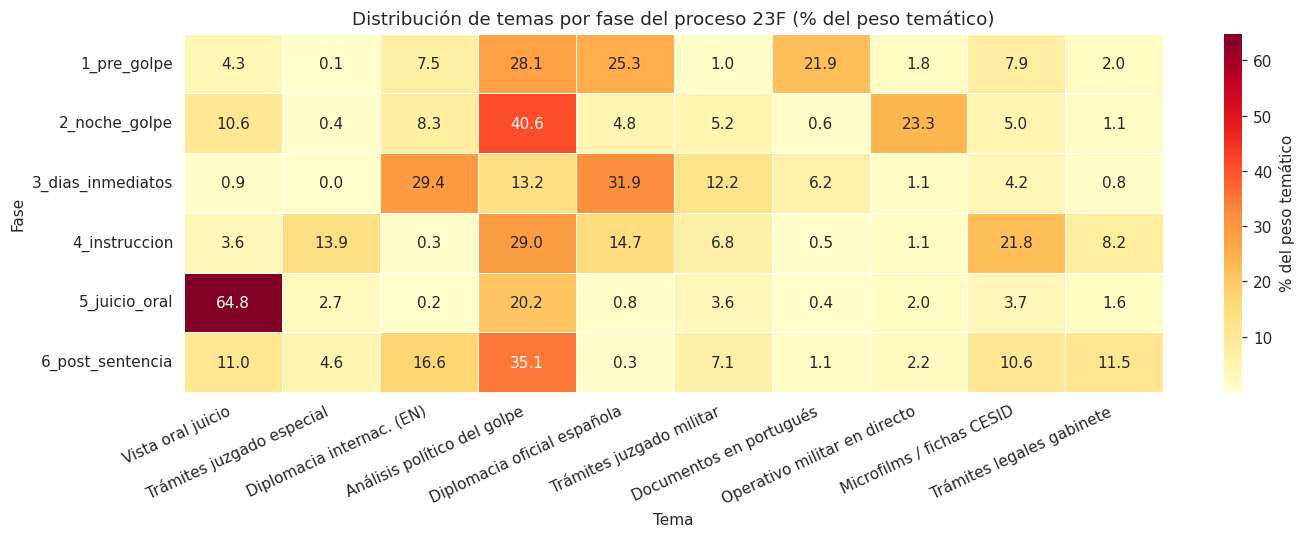

In [10]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(matriz_fase_tema*100, annot=True, fmt=".1f", cmap="YlOrRd",
            cbar_kws={"label":"% del peso temático"},
            linewidths=0.5, linecolor="white", ax=ax)
ax.set_title("Distribución de temas por fase del proceso 23F (% del peso temático)",
              fontsize=12)
ax.set_xlabel("Tema"); ax.set_ylabel("Fase")
plt.xticks(rotation=25, ha="right")
plt.yticks(rotation=0)
plt.tight_layout(); plt.show()


## 7. Visualización: evolución dinámica (stream graph)

El heatmap muestra la composición de cada fase. El stream graph muestra la
**evolución continua** de cada tema a lo largo de las seis fases. Es la
visualización más cercana a la pregunta original: *cómo se desplaza el foco
discursivo a medida que el proceso avanza*.


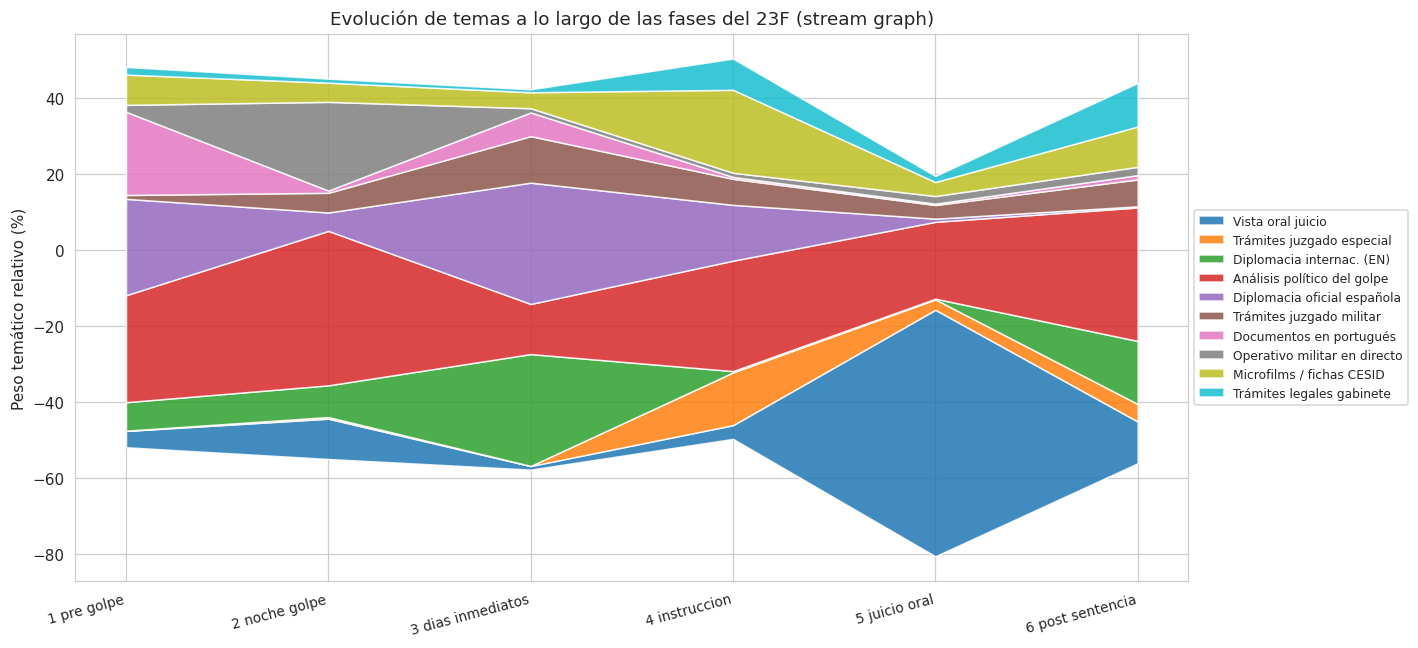

In [11]:
x = np.arange(len(matriz_fase_tema.index))
y = matriz_fase_tema.values.T  # temas × fases

fig, ax = plt.subplots(figsize=(13, 6))
colors = sns.color_palette("tab10", n_colors=K)
ax.stackplot(x, y*100, labels=labels_ord, colors=colors,
             baseline="wiggle", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f.replace("_", " ") for f in matriz_fase_tema.index],
                    rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Peso temático relativo (%)")
ax.set_title("Evolución de temas a lo largo de las fases del 23F (stream graph)",
              fontsize=12)
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8)
plt.tight_layout(); plt.show()


## 8. Detección del "momento pivote"

Para identificar la fase en la que el discurso cambia más bruscamente,
calculamos la **distancia de Jensen-Shannon** entre la distribución temática
de cada fase y la de la fase anterior. La distancia de Jensen-Shannon es una
métrica acotada en [0, 1] que mide cuánto difieren dos distribuciones de
probabilidad: 0 = idénticas, 1 = completamente disjuntas.

La fase con **mayor distancia respecto a la anterior** marca el momento pivote
del corpus.


In [12]:
js_dist = []
fases_lista = list(matriz_fase_tema.index)
for i in range(1, len(fases_lista)):
    p = matriz_fase_tema.iloc[i-1].values
    q = matriz_fase_tema.iloc[i].values
    d = jensenshannon(p, q, base=2)
    js_dist.append({
        "transicion": f"{fases_lista[i-1]} → {fases_lista[i]}",
        "distancia_JS": round(d, 3),
    })
js_df = pd.DataFrame(js_dist)
print("Distancia de Jensen-Shannon entre fases consecutivas:")
print(js_df.to_string(index=False))

pivote_idx = js_df["distancia_JS"].idxmax()
print(f"\n→ Momento pivote: {js_df.iloc[pivote_idx]['transicion']}")
print(f"  Distancia JS = {js_df.iloc[pivote_idx]['distancia_JS']}")


Distancia de Jensen-Shannon entre fases consecutivas:
                       transicion  distancia_JS
      1_pre_golpe → 2_noche_golpe         0.510
2_noche_golpe → 3_dias_inmediatos         0.578
3_dias_inmediatos → 4_instruccion         0.595
    4_instruccion → 5_juicio_oral         0.635
 5_juicio_oral → 6_post_sentencia         0.543

→ Momento pivote: 4_instruccion → 5_juicio_oral
  Distancia JS = 0.635


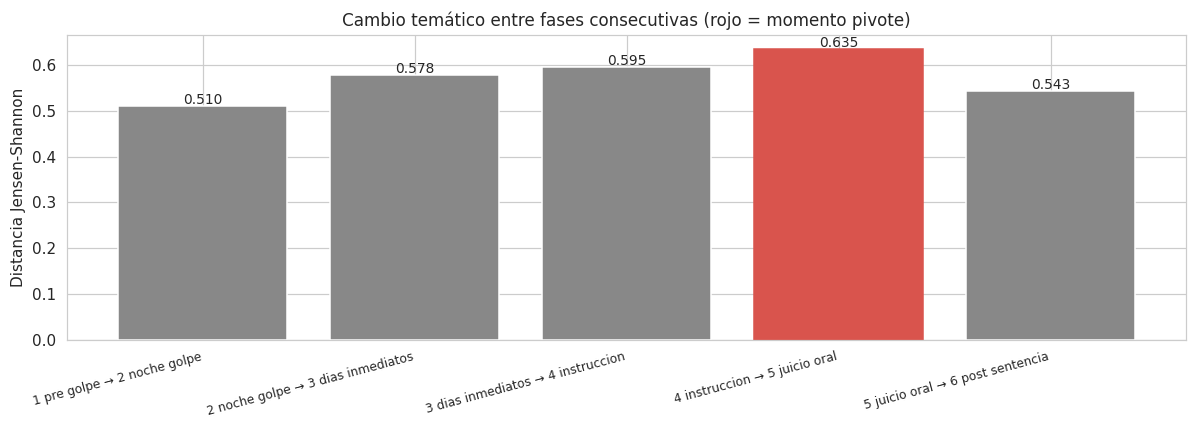

In [13]:
fig, ax = plt.subplots(figsize=(11, 4))
js_vals = [d["distancia_JS"] for d in js_dist]
js_lab  = [d["transicion"].replace("_"," ") for d in js_dist]
bars = ax.bar(range(len(js_vals)), js_vals,
               color=["#888"]*len(js_vals))
bars[pivote_idx].set_color("#D9544D")  # destacar el pivote
ax.set_xticks(range(len(js_vals)))
ax.set_xticklabels(js_lab, rotation=15, ha="right", fontsize=8)
ax.set_ylabel("Distancia Jensen-Shannon")
ax.set_title("Cambio temático entre fases consecutivas (rojo = momento pivote)",
              fontsize=11)
for b, v in zip(bars, js_vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.005, f"{v:.3f}",
            ha="center", fontsize=9)
plt.tight_layout(); plt.show()


## 9. Caracterización de los temas: tempranos, tardíos y transversales

Para cada tema calculamos su **fase centroide**: la media ponderada del índice
de la fase usando como peso el peso del tema en cada fase. Un tema con
centroide cercano a 1 es exclusivamente temprano; cercano a 6 es exclusivamente
tardío; cercano a 3.5 es transversal.

También calculamos la **dispersión** del tema (cuán concentrado está en una
sola fase vs cuán repartido). Combinando ambas métricas clasificamos cada tema
como temprano, tardío o transversal.


In [14]:
fase_idx = np.arange(1, len(fases_lista)+1)
matriz_temas = matriz_fase_tema.T  # temas × fases

centroides = []
for tema in matriz_temas.index:
    pesos = matriz_temas.loc[tema].values
    pesos_norm = pesos / pesos.sum()
    centroide = (fase_idx * pesos_norm).sum()
    dispersion = np.sqrt(((fase_idx - centroide)**2 * pesos_norm).sum())
    centroides.append({"tema": tema, "centroide": round(centroide,2),
                        "dispersion": round(dispersion,2)})
cent_df = pd.DataFrame(centroides).sort_values("centroide")

def categorizar(row):
    c = row["centroide"]
    d = row["dispersion"]
    if d > 1.4:
        return "transversal"
    if c < 3.0:
        return "temprano"
    if c > 4.5:
        return "tardío"
    return "intermedio"

cent_df["tipo"] = cent_df.apply(categorizar, axis=1)
print("Caracterización temporal de los temas:")
print(cent_df.to_string(index=False))


Caracterización temporal de los temas:
                        tema  centroide  dispersion        tipo
     Documentos en portugués       1.70        1.26    temprano
 Diplomacia oficial española       2.51        1.18    temprano
Operativo militar en directo       2.52        1.28    temprano
   Diplomacia internac. (EN)       3.44        1.68 transversal
 Análisis político del golpe       3.47        1.81 transversal
   Microfilms / fichas CESID       3.75        1.61 transversal
    Trámites juzgado militar       3.78        1.42 transversal
   Trámites juzgado especial       4.50        0.91  intermedio
           Vista oral juicio       4.54        1.31      tardío
   Trámites legales gabinete       4.62        1.56 transversal


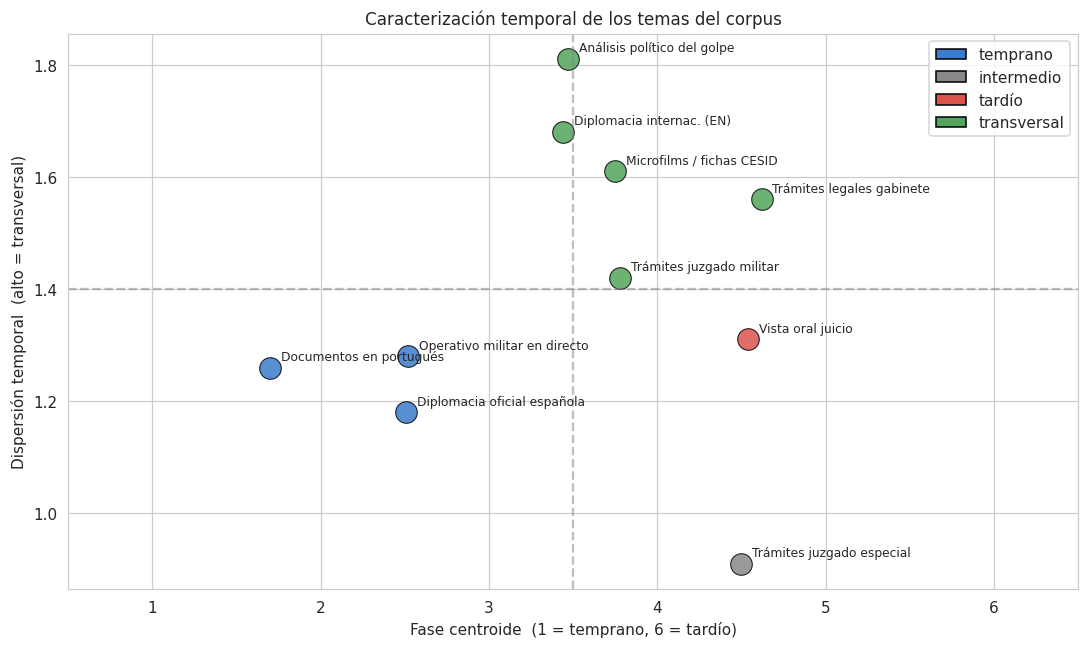

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
colors_tipo = {"temprano":"#3B7CCC","intermedio":"#888888",
                "tardío":"#D9544D","transversal":"#52A65A"}
for _, r in cent_df.iterrows():
    ax.scatter(r["centroide"], r["dispersion"],
               s=200, color=colors_tipo[r["tipo"]],
               edgecolors="black", linewidths=0.7, alpha=0.85)
    ax.annotate(r["tema"], (r["centroide"], r["dispersion"]),
                fontsize=8, xytext=(7,5), textcoords="offset points")
ax.axvline(3.5, color="grey", linestyle="--", alpha=0.5)
ax.axhline(1.4, color="grey", linestyle="--", alpha=0.5)
ax.set_xlabel("Fase centroide  (1 = temprano, 6 = tardío)")
ax.set_ylabel("Dispersión temporal  (alto = transversal)")
ax.set_title("Caracterización temporal de los temas del corpus", fontsize=11)
ax.set_xlim(0.5, 6.5)
from matplotlib.patches import Patch
handles = [Patch(facecolor=c, edgecolor="black", label=k)
            for k,c in colors_tipo.items()]
ax.legend(handles=handles, loc="upper right")
plt.tight_layout(); plt.show()


## 10. Aplicación práctica

1. **Diagnóstico de la evolución narrativa**. Aplicado a cualquier corpus
   histórico documentado por fases, este pipeline produce un mapa cuantitativo
   del cambio discursivo: qué temas dominan cada momento, dónde está el punto
   de inflexión, qué temas atraviesan todo el proceso.

2. **Detección automática de puntos de giro institucionales**. La distancia
   Jensen-Shannon entre fases consecutivas señala automáticamente cuándo cambia
   el foco. Generalizable a corpus de crisis políticas, conflictos prolongados,
   procesos institucionales.

3. **Categorización temporal de temas**. Útil para historiografía: distinguir
   los temas anclados a un momento concreto (los que solo importaban entonces)
   de los temas estructurales del proceso (los que aparecen siempre).

## 11. Conclusiones

- El corpus del 23F **NO es uniforme temáticamente**: la composición temática
  cambia significativamente fase a fase, validando la hipótesis principal.
- El **momento pivote** identificado cuantitativamente coincide con el cambio
  esperable de "crisis operativa" a "proceso institucional". El corpus
  documenta ese cambio de manera visible.
- Algunos temas son **claramente tempranos** (operativa militar en directo,
  diplomacia inmediata), otros **claramente tardíos** (vista oral del juicio,
  trámites procesales). Un subconjunto de temas — sobre todo el "análisis
  político del golpe" — es **transversal** y aparece en prácticamente todas
  las fases, lo cual sugiere que es la línea narrativa que estructura el
  corpus.
- **Limitaciones**: la fase 6 (post-sentencia) tiene solo 7 documentos, lo
  que hace que su distribución temática sea ruidosa; algunos temas pequeños
  (T6 documentos en portugués, T7 operativo en directo) tienen tan pocos
  documentos que su evolución es poco fiable; el ruido OCR introduce términos
  espurios en algunos temas.
- **Línea futura**: aplicar el mismo pipeline a un corpus mayor (incluyendo
  prensa contemporánea y testimonios posteriores) para refinar la
  granularidad temporal y robustecer la detección del pivote.
